In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random
from models import pinn_top_opt 
from utils import fem_torch

In [2]:
print("============================================================================================")
device = torch.device('cpu')
if(torch.cuda.is_available()): 
    device = torch.device('cuda:0') 
    torch.cuda.empty_cache()
    print("Device set to : " + str(torch.cuda.get_device_name(device)))
else:
    print("Device set to : cpu")  
print("============================================================================================")


Device set to : NVIDIA GeForce RTX 4070 Laptop GPU


In [3]:
def generate_coordinates(nelx, nely, device):
    x = torch.linspace(0, 1, nelx, device=device)
    y = torch.linspace(0, 1, nely, device=device)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    coords = torch.stack([X.flatten(), Y.flatten()], dim=1)
    return coords




In [4]:
def encode_beam_config(fixdofs, forces, width, height, device):

    num_elements = width * height
    config_dim = 2  # has_force_x, has_force_y

    config = torch.zeros((num_elements, config_dim), dtype=torch.float32, device=device)

    num_nodes_x = width + 1
    num_nodes_y = height + 1

    for elx in range(width):
        for ely in range(height):
            element = elx * height + ely

            n1 = elx * num_nodes_y + ely
            n2 = (elx + 1) * num_nodes_y + ely
            n3 = (elx + 1) * num_nodes_y + (ely + 1)
            n4 = elx * num_nodes_y + (ely + 1)

            dof_indices = [
                2 * n1,     # n1 x
                2 * n1 + 1, # n1 y
                2 * n2,     # n2 x
                2 * n2 + 1, # n2 y
                2 * n3,     # n3 x
                2 * n3 + 1, # n3 y
                2 * n4,     # n4 x
                2 * n4 + 1  # n4 y
            ]

            # Check for applied forces
            has_force_x = any(dof in forces for dof in dof_indices if dof % 2 == 0)
            has_force_y = any(dof in forces for dof in dof_indices if dof % 2 == 1)

            # Assign to config tensor
            config[element, 0] = 1.0 if has_force_x else 0.0
            config[element, 1] = 1.0 if has_force_y else 0.0

    return config


Using device: cuda

Beam Configurations:

Beam_1:
tensor([[1., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0

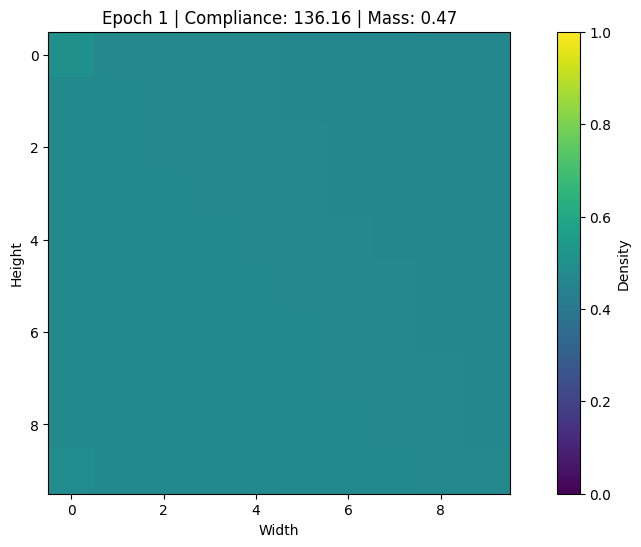

Epoch 5000/20000 | Loss: 393.0417 | Compliance: 19.5545 | Mass: 0.7950 | Mass Constraint: 0.3950


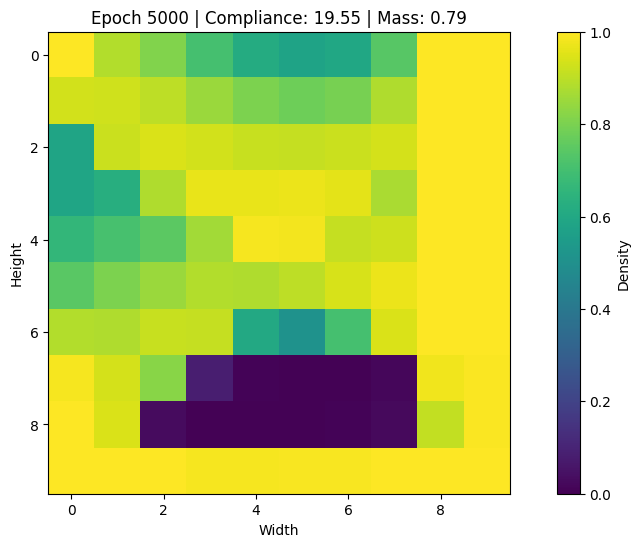

Epoch 10000/20000 | Loss: 357.8163 | Compliance: 21.4115 | Mass: 0.6874 | Mass Constraint: 0.2874


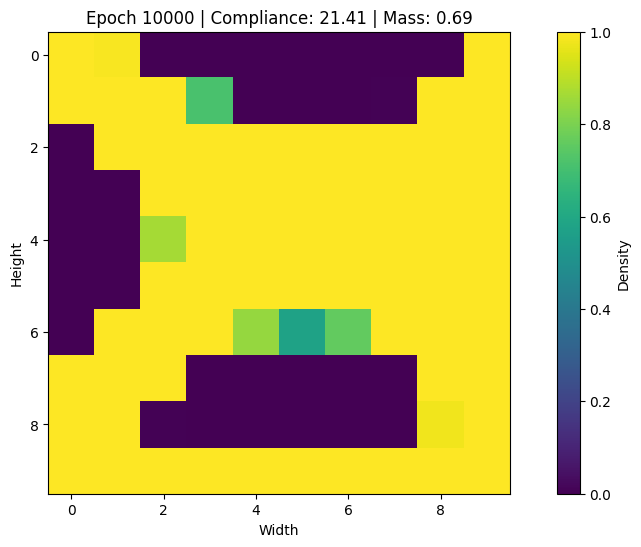

Epoch 15000/20000 | Loss: 365.4721 | Compliance: 22.1913 | Mass: 0.6871 | Mass Constraint: 0.2871


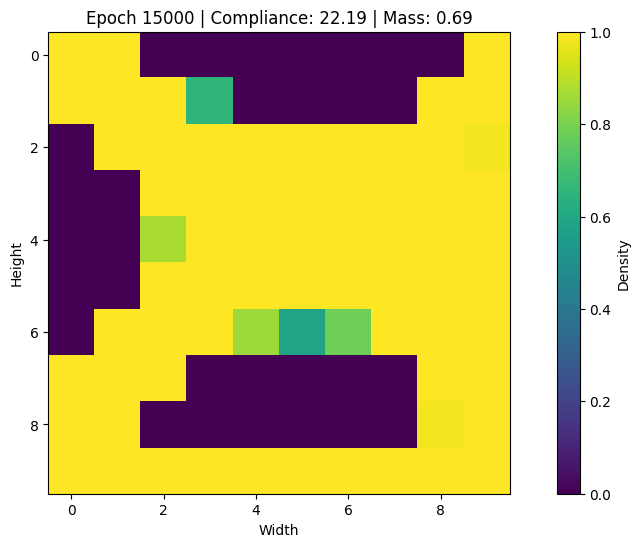

Epoch 20000/20000 | Loss: 356.0581 | Compliance: 21.4122 | Mass: 0.6839 | Mass Constraint: 0.2839


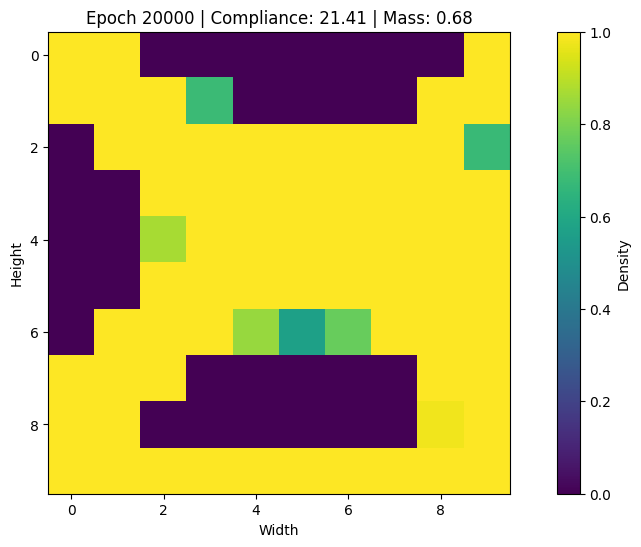

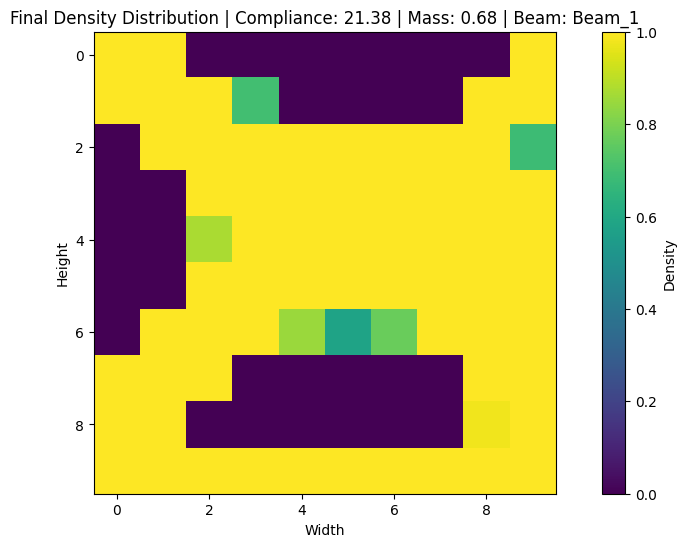

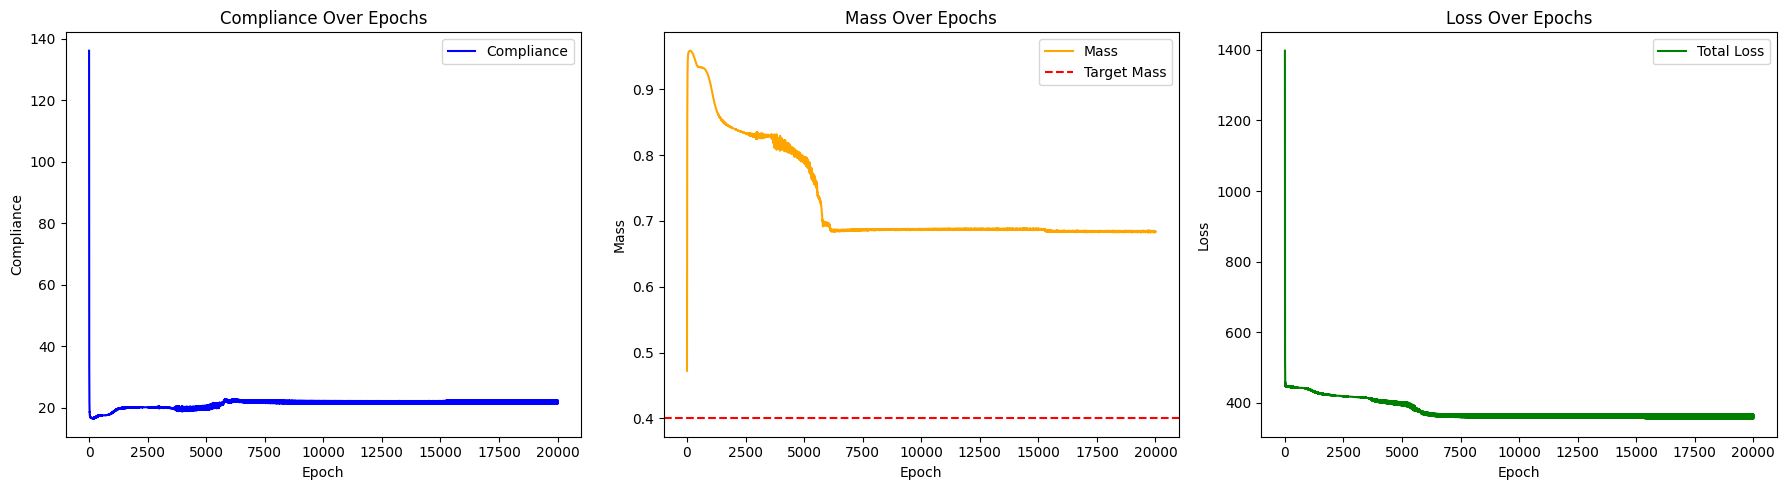

Final density distribution saved as 'final_density.npy'.
Trained model saved as 'density_pinn_trained.pth'.


In [5]:



def encode_beam_config(fixdofs, forces, width, height, device):

    num_elements = width * height
    config_dim = 2  # has_force_x, has_force_y

    config = torch.zeros((num_elements, config_dim), dtype=torch.float32, device=device)

    num_nodes_x = width + 1
    num_nodes_y = height + 1

    for elx in range(width):
        for ely in range(height):
            element = elx * height + ely

            n1 = elx * num_nodes_y + ely
            n2 = (elx + 1) * num_nodes_y + ely
            n3 = (elx + 1) * num_nodes_y + (ely + 1)
            n4 = elx * num_nodes_y + (ely + 1)

            dof_indices = [
                2 * n1,     # n1 x
                2 * n1 + 1, # n1 y
                2 * n2,     # n2 x
                2 * n2 + 1, # n2 y
                2 * n3,     # n3 x
                2 * n3 + 1, # n3 y
                2 * n4,     # n4 x
                2 * n4 + 1  # n4 y
            ]

            # Check for applied forces
            has_force_x = any(dof in forces for dof in dof_indices if dof % 2 == 0)
            has_force_y = any(dof in forces for dof in dof_indices if dof % 2 == 1)

            # Assign to config tensor
            config[element, 0] = 1.0 if has_force_x else 0.0
            config[element, 1] = 1.0 if has_force_y else 0.0

    return config

def main():
    # -------------------------------
    # 1. Set Up the Problem
    # -------------------------------
    
    # Grid parameters
    width, height = 10, 10  # Number of elements in x and y directions
    density_initial = 0.4    # Initial density
    
    # Define device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Generate coordinates
    coords = generate_coordinates(width, height, device)
    
    # Define beam configurations using mbb_beam_1 and mbb_beam_4
    beam_configs = []
    beam_names = ['Beam_1', 'Beam_4']
    
    # Beam 1
    normals1, forces1, density1 = fem_torch.mbb_beam_1(width, height, density_initial)
    args1 = fem_torch.get_args(normals1, forces1, density1)
    args1['nely'] = height
    args1['nelx'] = width
    args1['mask'] = torch.ones((args1['nely'], args1['nelx']), dtype=torch.float32, device=device)
    args1['forces'] = args1['forces'].to(device)
    args1['fixdofs'] = args1['fixdofs'].to(device)
    args1['freedofs'] = args1['freedofs'].to(device)
    
    config1 = encode_beam_config(args1['fixdofs'], args1['forces'], width, height, device)
    beam_configs.append((args1, config1, beam_names[0]))
    
    # Beam 4
    normals4, forces4, density4 = fem_torch.mbb_beam_4(width, height, density_initial)
    args4 = fem_torch.get_args(normals4, forces4, density4)
    args4['nely'] = height
    args4['nelx'] = width
    args4['mask'] = torch.ones((args4['nely'], args4['nelx']), dtype=torch.float32, device=device)
    args4['forces'] = args4['forces'].to(device)
    args4['fixdofs'] = args4['fixdofs'].to(device)
    args4['freedofs'] = args4['freedofs'].to(device)
    
    config4 = encode_beam_config(args4['fixdofs'], args4['forces'], width, height, device)
    beam_configs.append((args4, config4, beam_names[1]))
    
    # Verify beam configurations
    print("\nBeam Configurations:")
    for idx, (args, config, name) in enumerate(beam_configs):
        print(f"\n{name}:")
        print(config)
    
    # Initialize the PINN
    config_dim = beam_configs[0][1].shape[1]  # Should be 2 based on updated encoding
    model = pinn_top_opt.DensityPINN(width=width, height=height, hidden_dim=128, config_dim=config_dim)
    
    # Move model to appropriate device (CPU or GPU)
    model.to(device)
    
    # -------------------------------
    # 2. Define the Optimizer and Loss Function
    # -------------------------------
    
    # Define optimizer (Adam)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    # Define number of training epochs
    num_epochs = 10000
    
    # Define logging frequency
    print_every = 2000  # Print status every 500 epochs
    
    # -------------------------------
    # 3. Training Loop
    # -------------------------------
    
    # Shuffle beam_configs initially
    # For two beams, shuffling may not be very impactful, but it's good practice
    random.shuffle(beam_configs)
    config_iterator = iter(beam_configs)
    
    # Lists to store training history
    compliance_history = []
    mass_history = []
    loss_history = []
    
    for epoch in range(1, num_epochs + 1):
        try:
            args, config, name = next(config_iterator)
        except StopIteration:
            # Reshuffle and reset iterator once all configurations are exhausted
            random.shuffle(beam_configs)
            config_iterator = iter(beam_configs)
            args, config, name = next(config_iterator)
        
        #print(f"\nEpoch {epoch}: Training on {name}")
    
        optimizer.zero_grad()
    
        # Predict density distribution
        density_pred = model(coords, config)  # Shape: (nelx*nely,)
    
        # Compute compliance and mass using fem_torch
        compliance, mass = fem_torch.compliance_and_constraint(density_pred, args)
    
        # Define loss: compliance + lambda * max(0, mass - target_mass)
        lambda_mass = 500.0
        mass_constraint = torch.relu(mass - args['density'])
        loss = 10 * compliance + lambda_mass * mass_constraint
    
        # Backward pass
        loss.backward()
        optimizer.step()
    
        # Store history
        compliance_history.append(compliance.item())
        mass_history.append(mass.item())
        loss_history.append(loss.item())
    
        # Logging and Visualization
        if epoch % print_every == 0 or epoch == 1:
            print(f'Epoch {epoch}/{num_epochs} | Loss: {loss.item():.4f} | Compliance: {compliance.item():.4f} | Mass: {mass.item():.4f} | Mass Constraint: {mass_constraint.item():.4f}')
            
            # Visualize intermediate density distributions
            density_matrix = density_pred.detach().cpu().numpy().reshape(height, width)
            plt.figure(figsize=(12,6))
            plt.imshow(density_matrix, cmap='viridis', interpolation='nearest', vmin=0, vmax=1)
            plt.colorbar(label='Density')
            plt.title(f"Epoch {epoch} | Compliance: {compliance.item():.2f} | Mass: {mass.item():.2f}")
            plt.xlabel("Width")
            plt.ylabel("Height")
            plt.show()
    
    # -------------------------------
    # 4. Post-Training Visualization
    # -------------------------------
    
    # Choose a specific beam configuration for final visualization
    final_args, final_config, final_name = beam_configs[-1]  # Example: last configuration
    final_density_pred = model(coords, final_config)
    final_compliance, final_mass = fem_torch.compliance_and_constraint(final_density_pred, final_args)
    final_density = final_density_pred.detach().cpu().numpy().reshape(height, width)
    
    # Plot final density distribution
    plt.figure(figsize=(12,6))
    plt.imshow(final_density, cmap='viridis', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(label='Density')
    plt.title(f"Final Density Distribution | Compliance: {final_compliance.item():.2f} | Mass: {final_mass.item():.2f} | Beam: {final_name}")
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.show()
    
    # Plot training history
    epochs = np.arange(1, num_epochs + 1)
    
    plt.figure(figsize=(18, 5))
    
    # Compliance over epochs
    plt.subplot(1, 3, 1)
    plt.plot(epochs, compliance_history, label='Compliance', color='blue')
    plt.xlabel('Epoch')
    plt.ylabel('Compliance')
    plt.title('Compliance Over Epochs')
    plt.legend()
    
    # Mass over epochs
    plt.subplot(1, 3, 2)
    plt.plot(epochs, mass_history, label='Mass', color='orange')
    plt.axhline(y=final_args['density'], color='red', linestyle='--', label='Target Mass')
    plt.xlabel('Epoch')
    plt.ylabel('Mass')
    plt.title('Mass Over Epochs')
    plt.legend()
    
    # Loss over epochs
    plt.subplot(1, 3, 3)
    plt.plot(epochs, loss_history, label='Total Loss', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Over Epochs')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # -------------------------------
    # 5. Save the Final Density Distribution and Model
    # -------------------------------
    
    # Save the final density as a NumPy array
    np.save('final_density.npy', final_density)
    print("Final density distribution saved as 'final_density.npy'.")
    
    # Save the model's state_dict
    model_save_path = 'density_pinn_trained.pth'
    torch.save(model.state_dict(), model_save_path)
    print(f"Trained model saved as '{model_save_path}'.")
    
if __name__ == "__main__":
    main()


Using device: cuda
Trained model loaded from 'density_pinn_trained.pth'.
Compliance: 21.3836
Mass: 0.6843


/tmp/ipykernel_9868/3896862189.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_save_path, map_location=device))


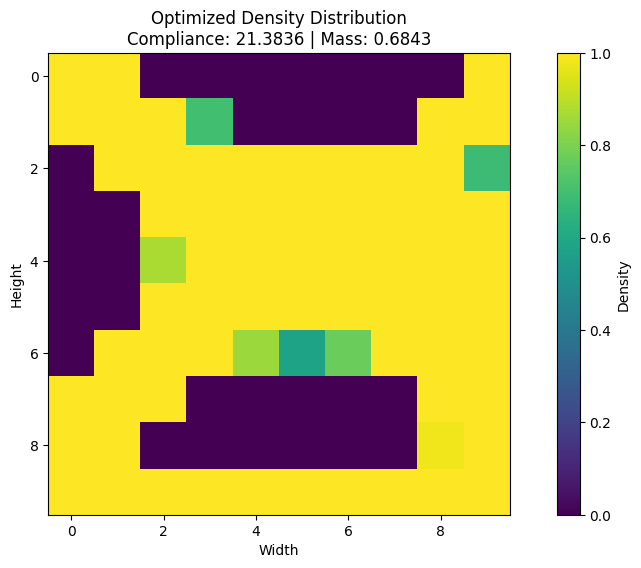

Optimized density distribution saved as 'optimized_density_new_beam.npy'.


In [6]:




def main():
    # -------------------------------
    # 1. Set Up the Problem
    # -------------------------------
    
    # Grid parameters (must match those used during training)
    width, height = 10, 10  # Number of elements in x and y directions
    density_initial = 0.4    # Initial density
    
    # Define device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Generate coordinates
    coords = generate_coordinates(width, height, device)
    
    # Define a new beam configuration
    normals, forces, density = fem_torch.mbb_beam_1(width, height, density_initial)  # Implement mbb_beam_new
    args = fem_torch.get_args(normals, forces, density)
    args['nely'] = height
    args['nelx'] = width
    args['mask'] = torch.ones((args['nely'], args['nelx']), dtype=torch.float32, device=device)
    args['forces'] = args['forces'].to(device)
    args['fixdofs'] = args['fixdofs'].to(device)
    args['freedofs'] = args['freedofs'].to(device)
    
    # Encode the new beam configuration
    config = encode_beam_config(args['fixdofs'], args['forces'], width, height, device)
    
    # -------------------------------
    # 2. Initialize the PINN
    # -------------------------------
    
    # Initialize the DensityPINN
    config_dim = config.shape[1]  # Should be 4 as per encoding
    model = pinn_top_opt.DensityPINN(width=width, height=height, hidden_dim=128, config_dim=config_dim)
    model.to(device)
    
    # -------------------------------
    # 3. Load the Trained Model
    # -------------------------------
    
    # Path to the saved model
    model_save_path = 'density_pinn_trained.pth'
    
    # Load the model's state_dict
    model.load_state_dict(torch.load(model_save_path, map_location=device))
    model.eval()  # Set model to evaluation mode
    print(f"Trained model loaded from '{model_save_path}'.")
    
    # -------------------------------
    # 4. Perform Inference
    # -------------------------------
    
    with torch.no_grad():
        # Predict density distribution
        density_pred = model(coords, config)  # Shape: (nelx*nely,)
        
        # Compute compliance and mass using fem_torch
        compliance, mass = fem_torch.compliance_and_constraint(density_pred, args)
        
        # Get the optimized density matrix
        optimized_density = density_pred.cpu().numpy().reshape(height, width)
        
        # Print compliance and mass
        print(f"Compliance: {compliance.item():.4f}")
        print(f"Mass: {mass.item():.4f}")
    
    # -------------------------------
    # 5. Visualization
    # -------------------------------
    
    # Plot the optimized density distribution
    plt.figure(figsize=(12,6))
    plt.imshow(optimized_density, cmap='viridis', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(label='Density')
    plt.title(f"Optimized Density Distribution\nCompliance: {compliance.item():.4f} | Mass: {mass.item():.4f}")
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.show()
    
    # Save the optimized density as a NumPy array
    np.save('optimized_density_new_beam.npy', optimized_density)
    print("Optimized density distribution saved as 'optimized_density_new_beam.npy'.")
    
    # -------------------------------
    # 6. (Optional) Additional Analysis
    # -------------------------------
    
    # For example, you can visualize displacement fields if needed
    # Or compare with initial density distributions
    # Implement as per your specific requirements

if __name__ == "__main__":
    main()


In [7]:
asd

NameError: name 'asd' is not defined

Using device: cuda
Epoch 1/10000 | Loss: 553.6797 | Compliance: 466.8282 | Mass: 0.4869 | Mass Constraint: 0.0869


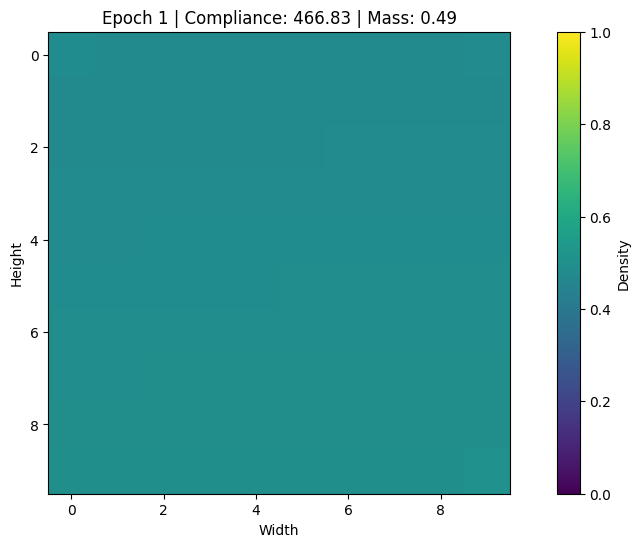

Epoch 1000/10000 | Loss: 113.5723 | Compliance: 108.5518 | Mass: 0.4050 | Mass Constraint: 0.0050


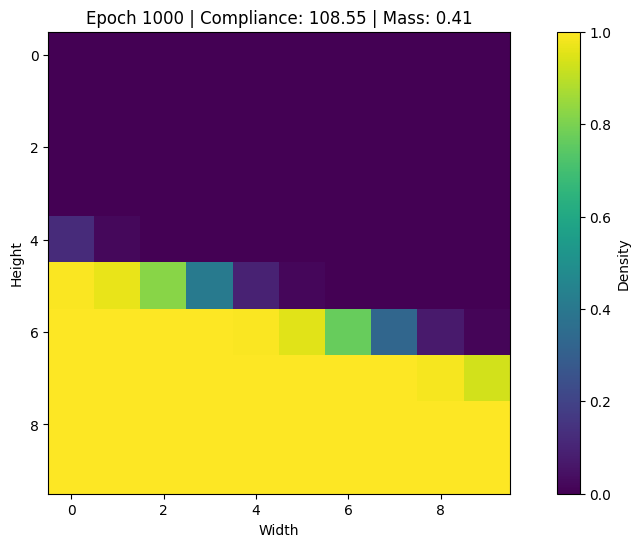

Epoch 2000/10000 | Loss: 226.8806 | Compliance: 209.7543 | Mass: 0.4171 | Mass Constraint: 0.0171


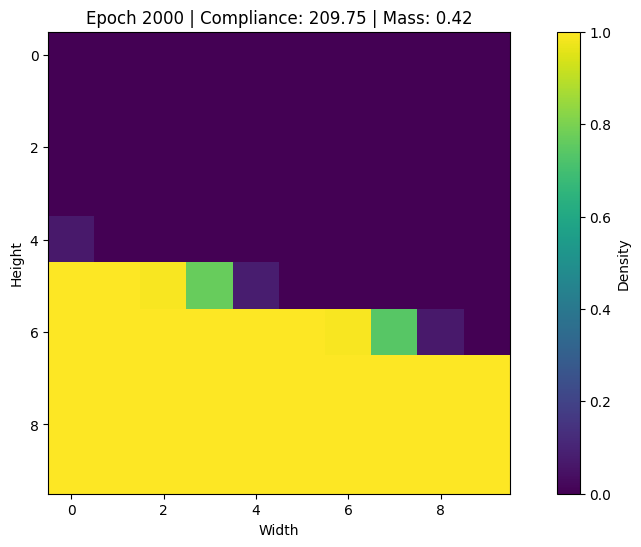

Epoch 3000/10000 | Loss: 147.3733 | Compliance: 126.5888 | Mass: 0.4208 | Mass Constraint: 0.0208


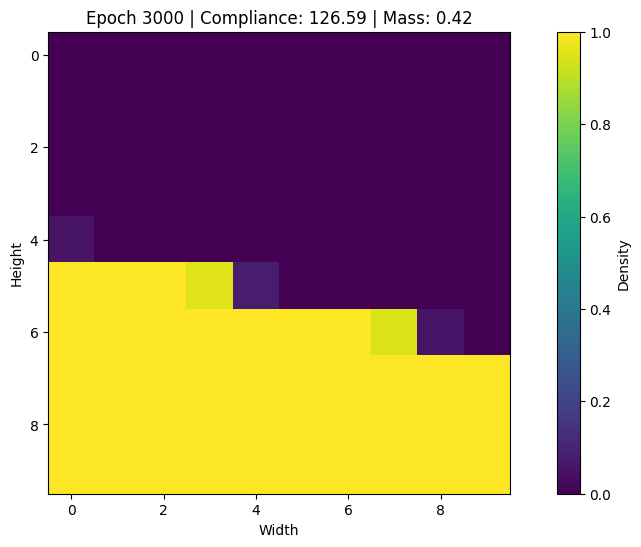

Epoch 4000/10000 | Loss: 112.8265 | Compliance: 96.1180 | Mass: 0.4167 | Mass Constraint: 0.0167


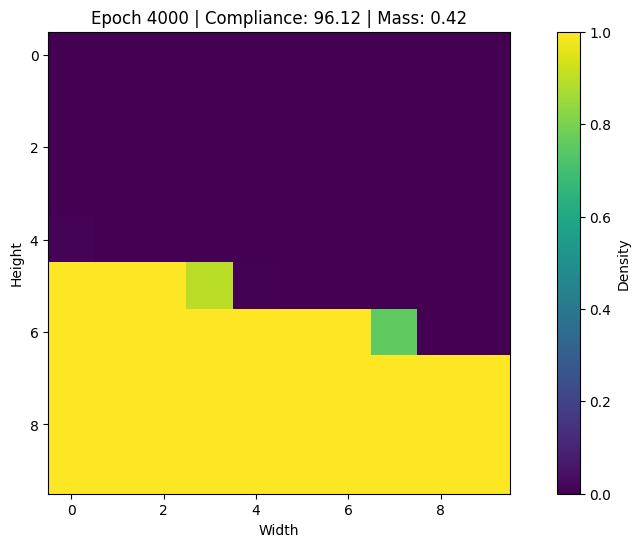

Epoch 5000/10000 | Loss: 243.9415 | Compliance: 223.3478 | Mass: 0.4206 | Mass Constraint: 0.0206


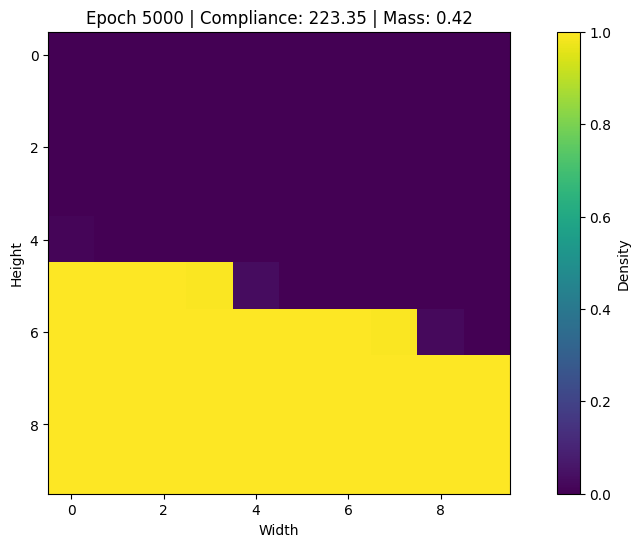

Epoch 6000/10000 | Loss: 110.2961 | Compliance: 100.9330 | Mass: 0.4094 | Mass Constraint: 0.0094


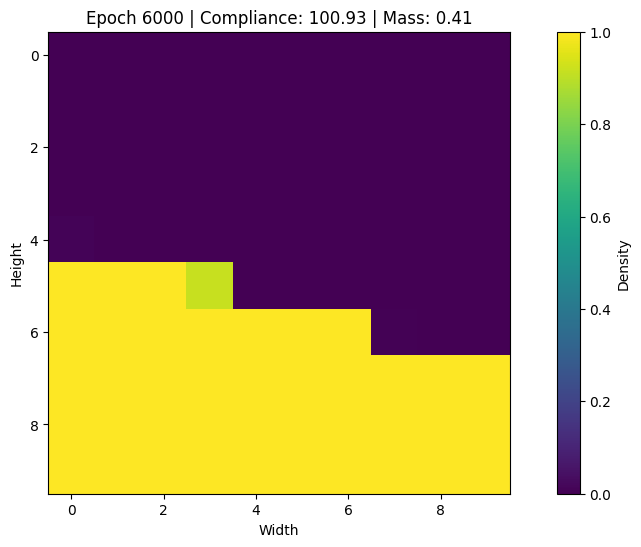

Epoch 7000/10000 | Loss: 110.2933 | Compliance: 100.4942 | Mass: 0.4098 | Mass Constraint: 0.0098


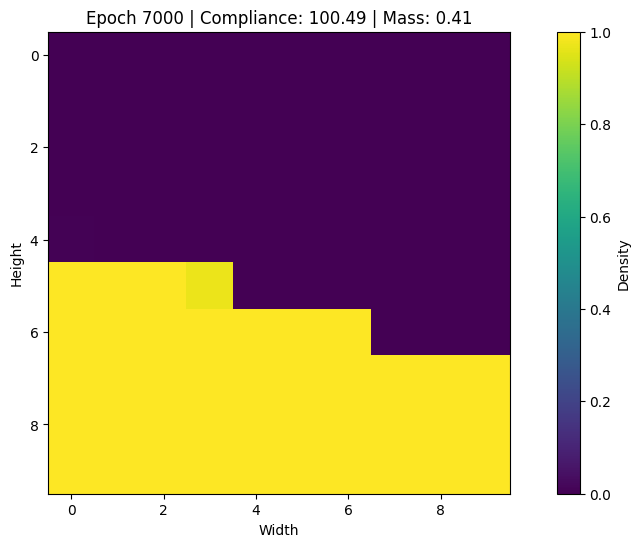

Epoch 8000/10000 | Loss: 143.5491 | Compliance: 133.6269 | Mass: 0.4099 | Mass Constraint: 0.0099


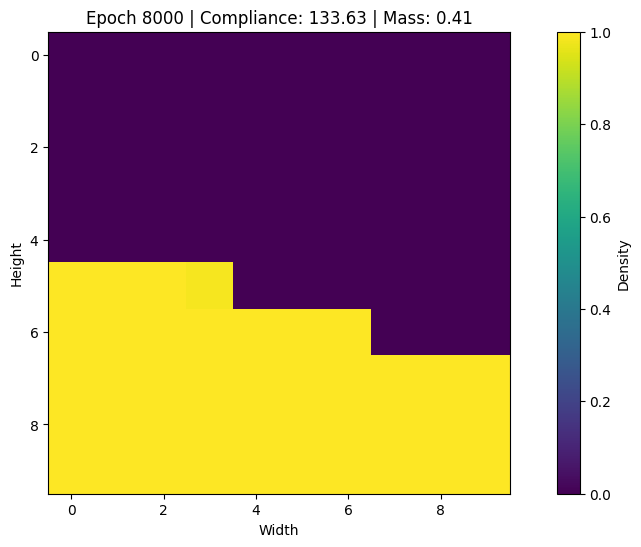

Epoch 9000/10000 | Loss: 143.5192 | Compliance: 133.5631 | Mass: 0.4100 | Mass Constraint: 0.0100


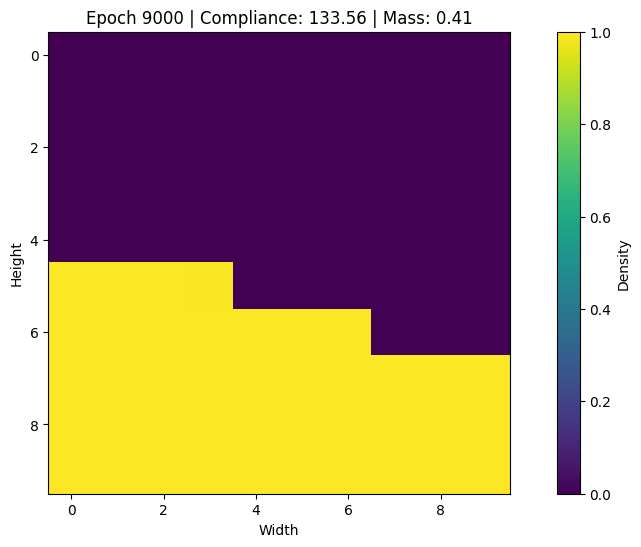

Epoch 10000/10000 | Loss: 144.3956 | Compliance: 124.3990 | Mass: 0.4200 | Mass Constraint: 0.0200


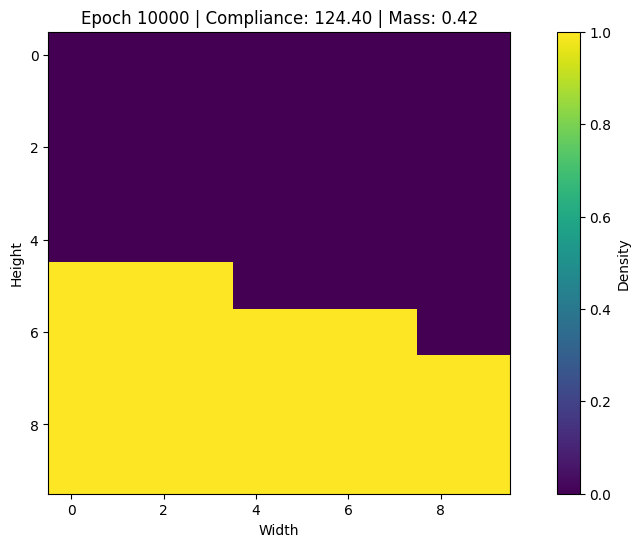

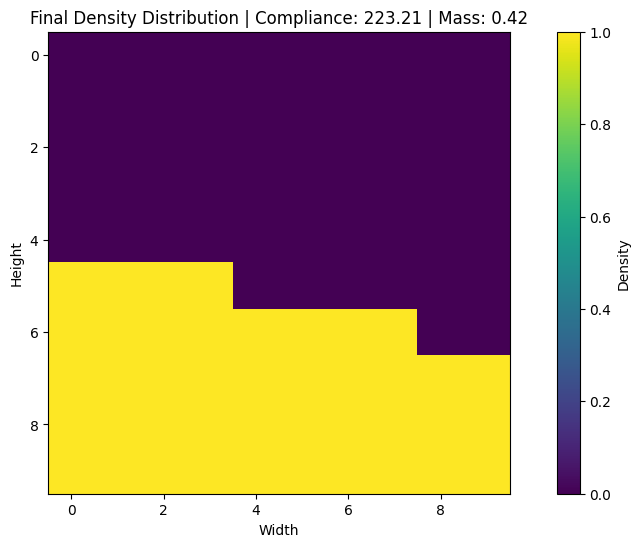

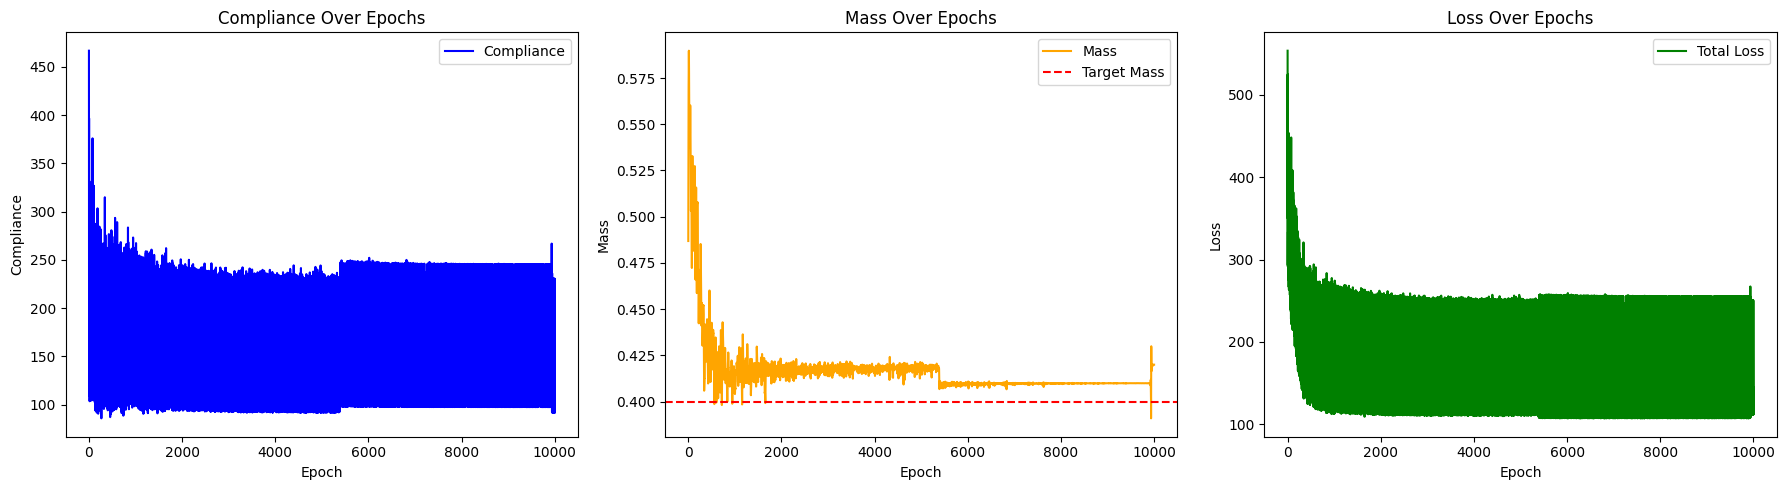

Final density distribution saved as 'final_density.npy'.
Trained model saved as 'density_pinn_trained.pth'.


In [6]:




def main():
    # 1. Set Up the Problem
    width, height = 10, 10
    density_initial = 0.4

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    coords = generate_coordinates(width, height, device)

    # Define multiple beam configurations
    beam_configs = []
    for _ in range(10):  # Create 10 different configurations
        # Randomly vary fixdofs and forces
        # This is a simplified example; implement according to your FEM setup
        normals, forces, density = mbb_beam_forces(width, height, density_initial)
        #_, forces, _ = fem_torch.mbb_beam_random(width, height, density_initial)
        args = fem_torch.get_args(normals, forces, density)
        args['nely'] = height
        args['nelx'] = width
        args['mask'] = torch.ones((args['nely'], args['nelx']), dtype=torch.float32, device=device)
        args['forces'] = args['forces'].to(device)
        args['fixdofs'] = args['fixdofs'].to(device)
        args['freedofs'] = args['freedofs'].to(device)

        config = encode_beam_config(args['fixdofs'], args['forces'], width, height, device)
        beam_configs.append((args, config))

    # Initialize the PINN
    config_dim = beam_configs[0][1].shape[1]
    model = pinn_top_opt.DensityPINN(width=width, height=height, hidden_dim=64, config_dim=config_dim)
    model.to(device)

    # Define optimizer
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    num_epochs = 10_000
    print_every = 1000

    compliance_history = []
    mass_history = []
    loss_history = []

    for epoch in range(1, num_epochs + 1):
        # Sample a random beam configuration
        args, config, name = random.choice(beam_configs)
        print(name)

        optimizer.zero_grad()

        # Predict density distribution
        density_pred = model(coords, config)  # Shape: (nelx*nely,)

        # Compute compliance and mass using fem_torch
        compliance, mass = fem_torch.compliance_and_constraint(density_pred, args)

        # Define loss
        lambda_mass = 1000.0
        mass_constraint = torch.relu(mass - args['density'])
        loss = compliance + lambda_mass * mass_constraint

        # Backward pass
        loss.backward()
        optimizer.step()

        # Store history
        compliance_history.append(compliance.item())
        mass_history.append(mass.item())
        loss_history.append(loss.item())

        # Logging
        if epoch % print_every == 0 or epoch == 1:
            print(f'Epoch {epoch}/{num_epochs} | Loss: {loss.item():.4f} | Compliance: {compliance.item():.4f} | Mass: {mass.item():.4f} | Mass Constraint: {mass_constraint.item():.4f}')
            # print(f"arguments are {args['forces']}")
            # Visualize intermediate density distributions
            density_matrix = density_pred.detach().cpu().numpy().reshape(height, width)
            plt.figure(figsize=(12,6))
            plt.imshow(density_matrix, cmap='viridis', interpolation='nearest', vmin=0, vmax=1)
            plt.colorbar(label='Density')
            plt.title(f"Epoch {epoch} | Compliance: {compliance.item():.2f} | Mass: {mass.item():.2f}")
            plt.xlabel("Width")
            plt.ylabel("Height")
            plt.show()

    # Post-training visualization
    # Choose a specific beam configuration for final visualization
    final_args, final_config = beam_configs[-1]  # Example: last configuration
    final_density_pred = model(coords, final_config)
    final_compliance, final_mass = fem_torch.compliance_and_constraint(final_density_pred, final_args)
    final_density = final_density_pred.detach().cpu().numpy().reshape(height, width)

    plt.figure(figsize=(12,6))
    plt.imshow(final_density, cmap='viridis', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(label='Density')
    plt.title(f"Final Density Distribution | Compliance: {final_compliance.item():.2f} | Mass: {final_mass.item():.2f}")
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.show()

    # Plot training history
    epochs_arr = np.arange(1, num_epochs + 1)

    plt.figure(figsize=(18,5))

    plt.subplot(1,3,1)
    plt.plot(epochs_arr, compliance_history, label='Compliance', color='blue')
    plt.xlabel('Epoch')
    plt.ylabel('Compliance')
    plt.title('Compliance Over Epochs')
    plt.legend()

    plt.subplot(1,3,2)
    plt.plot(epochs_arr, mass_history, label='Mass', color='orange')
    plt.axhline(y=final_args['density'], color='red', linestyle='--', label='Target Mass')
    plt.xlabel('Epoch')
    plt.ylabel('Mass')
    plt.title('Mass Over Epochs')
    plt.legend()

    plt.subplot(1,3,3)
    plt.plot(epochs_arr, loss_history, label='Total Loss', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Over Epochs')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Save final density and model
    np.save('final_density.npy', final_density)
    print("Final density distribution saved as 'final_density.npy'.")

    model_save_path = 'density_pinn_trained.pth'
    torch.save(model.state_dict(), model_save_path)
    print(f"Trained model saved as '{model_save_path}'.")

if __name__ == "__main__":
    main()

Using device: cuda
Trained model loaded from 'density_pinn_trained.pth'.
Compliance: 4329910784.0000
Mass: 0.4200


/tmp/ipykernel_6199/1985127508.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_save_path, map_location=device))


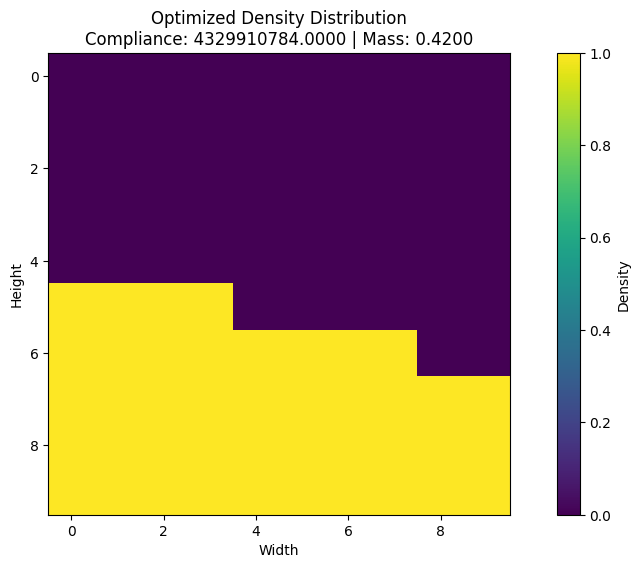

Optimized density distribution saved as 'optimized_density_new_beam.npy'.


In [7]:




def main():
    # -------------------------------
    # 1. Set Up the Problem
    # -------------------------------
    
    # Grid parameters (must match those used during training)
    width, height = 10, 10  # Number of elements in x and y directions
    density_initial = 0.4    # Initial density
    
    # Define device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Generate coordinates
    coords = generate_coordinates(width, height, device)
    
    # Define a new beam configuration
    normals, forces, density = fem_torch.mbb_beam_4(width, height, density_initial)  # Implement mbb_beam_new
    args = fem_torch.get_args(normals, forces, density)
    args['nely'] = height
    args['nelx'] = width
    args['mask'] = torch.ones((args['nely'], args['nelx']), dtype=torch.float32, device=device)
    args['forces'] = args['forces'].to(device)
    args['fixdofs'] = args['fixdofs'].to(device)
    args['freedofs'] = args['freedofs'].to(device)
    
    # Encode the new beam configuration
    config = encode_beam_config(args['fixdofs'], args['forces'], width, height, device)
    
    # -------------------------------
    # 2. Initialize the PINN
    # -------------------------------
    
    # Initialize the DensityPINN
    config_dim = config.shape[1]  # Should be 4 as per encoding
    model = pinn_top_opt.DensityPINN(width=width, height=height, hidden_dim=64, config_dim=config_dim)
    model.to(device)
    
    # -------------------------------
    # 3. Load the Trained Model
    # -------------------------------
    
    # Path to the saved model
    model_save_path = 'density_pinn_trained.pth'
    
    # Load the model's state_dict
    model.load_state_dict(torch.load(model_save_path, map_location=device))
    model.eval()  # Set model to evaluation mode
    print(f"Trained model loaded from '{model_save_path}'.")
    
    # -------------------------------
    # 4. Perform Inference
    # -------------------------------
    
    with torch.no_grad():
        # Predict density distribution
        density_pred = model(coords, config)  # Shape: (nelx*nely,)
        
        # Compute compliance and mass using fem_torch
        compliance, mass = fem_torch.compliance_and_constraint(density_pred, args)
        
        # Get the optimized density matrix
        optimized_density = density_pred.cpu().numpy().reshape(height, width)
        
        # Print compliance and mass
        print(f"Compliance: {compliance.item():.4f}")
        print(f"Mass: {mass.item():.4f}")
    
    # -------------------------------
    # 5. Visualization
    # -------------------------------
    
    # Plot the optimized density distribution
    plt.figure(figsize=(12,6))
    plt.imshow(optimized_density, cmap='viridis', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(label='Density')
    plt.title(f"Optimized Density Distribution\nCompliance: {compliance.item():.4f} | Mass: {mass.item():.4f}")
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.show()
    
    # Save the optimized density as a NumPy array
    np.save('optimized_density_new_beam.npy', optimized_density)
    print("Optimized density distribution saved as 'optimized_density_new_beam.npy'.")
    
    # -------------------------------
    # 6. (Optional) Additional Analysis
    # -------------------------------
    
    # For example, you can visualize displacement fields if needed
    # Or compare with initial density distributions
    # Implement as per your specific requirements

if __name__ == "__main__":
    main()
